# Results FCBG Connectome Registration

Visualisation of metabolite concentration maps (MRSI) overlaid on the T1w UNI-DEN background.


In [21]:
%run main.py
from utils import (
    img_info,
    plot_single_overlay,
    plot_support_mask,
    plot_coverage_grid,
    plot_mrsi_mosaic,
    plot_mrsi_combined,
    build_coverage_widget,
    plot_t1w_mrs_comparison,
    rank_metabolites_by_snr,
    plot_snr_ranking,
    plot_water_mask_comparison,
    plot_registration_comparison,
    plot_registration_methods_comparison,
    plot_registration_target_comparison,
    plot_coverage_registration_comparison,
    compare_registration_coverage,
    plot_sum_registration_comparison,
)


  [sum] sub-01: saved sub-01_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (38 maps summed)
  [sum] sub-02: saved sub-02_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (39 maps summed)
  [sum] sub-03: saved sub-03_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (39 maps summed)
  [sum] sub-04: saved sub-04_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (39 maps summed)
  [sum] sub-05: saved sub-05_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (39 maps summed)
  [t1w-ds] sub-01: saved sub-01_ses-01_acq-MRSIres_T1w.nii.gz  (T1w (224, 272, 288) to MRS grid (74, 74, 37))
  [t1w-ds] sub-02: T1w not found (sub-02_ses-01_acq-UNIDEN_T1w.nii), skipping.
  [t1w-ds] sub-03: T1w not found (sub-03_ses-01_acq-UNIDEN_T1w.nii), skipping.
  [t1w-ds] sub-04: T1w not found (sub-04_ses-01_acq-UNIDEN_T1w.nii), skipping.
  [t1w-ds] sub-05: T1w not found (sub-05_ses-01_acq-UNIDEN_T1w.nii), skipping.
  [reg] saved registered MRSI: /Users/user/FCBG_project_Connectome_registraction/Code/data/output/s

## 1 – Sanity check: image shapes & voxel sizes

In [22]:
img_info(t1w_img,     "T1w UNI-DEN")
img_info(mrs_example, f"MRS – {mrs_files[0]}")

T1w UNI-DEN
  shape      : (224, 272, 288)
  voxel size : [0.8   0.799 0.799] mm
  dtype      : int16

MRS – sub-01_ses-01_acq-OrigRes_desc-2HG_mrsi.nii.gz
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32



## 2 – Single metabolite overlay on T1w

`plot_single_overlay` canonicalizes orientations, resamples MRSI to T1 grid, and plots 3 orthogonal views.  
Change `METABOLITE` to any label available in `mrs_files`.

Showing: sub-01_ses-01_acq-OrigRes_desc-NAA_mrsi.nii.gz


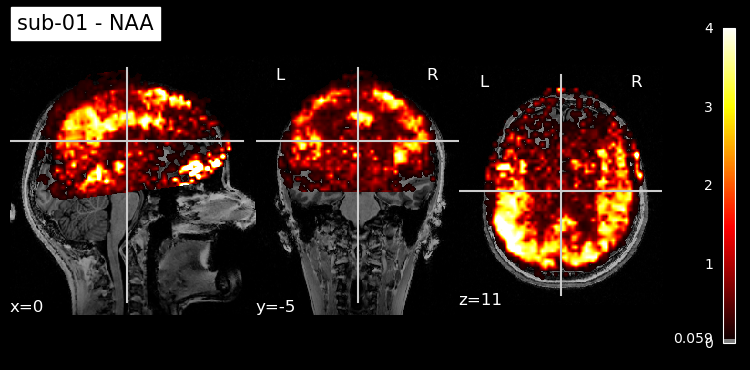

  Brain coverage: 18.6%


In [23]:
METABOLITE = "NAA"   # change to any metabolite label (e.g. "Cr", "Glu", "GABA")
match = [f for f in mrs_files if f"desc-{METABOLITE}_" in f]
if not match:
    print(f"No file found for metabolite '{METABOLITE}'")
else:
    print(f"Showing: {match[0]}")
    plot_single_overlay(match[0], T1W_PATH, MRS_DIR, subj=SUBJ)


## 3 – Coverage check: do the MRSI maps cover the whole brain?

Overlay several metabolite maps on the T1w in a single figure  so we can directly compare spatial coverage across metabolites.

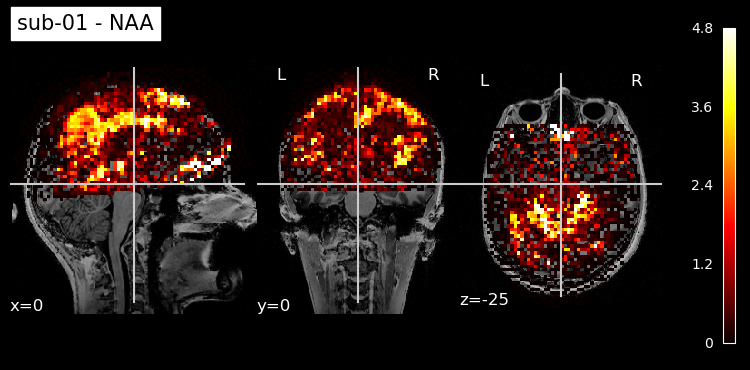

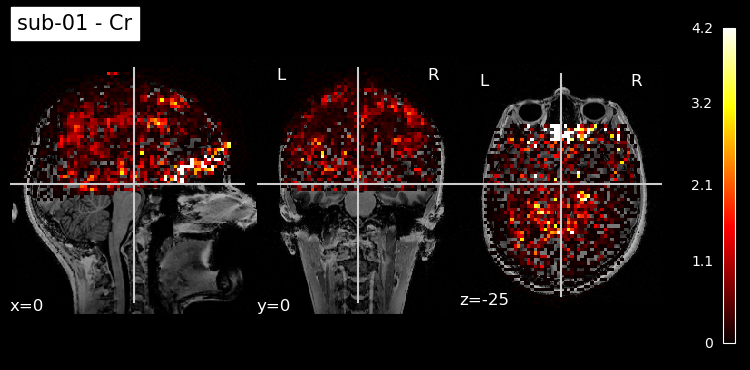

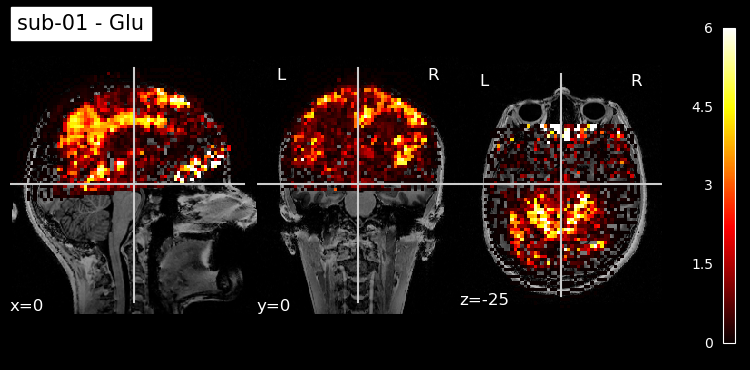

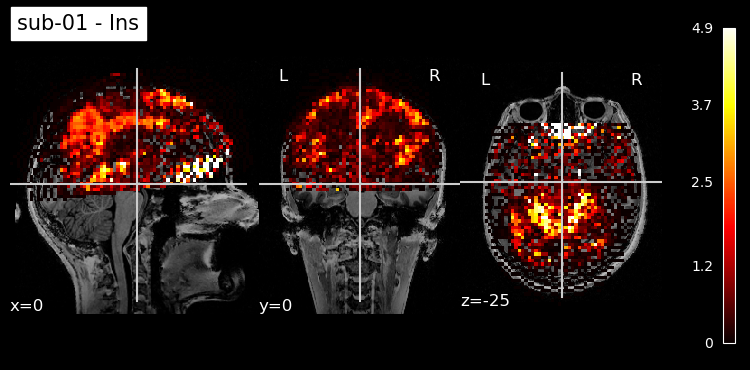

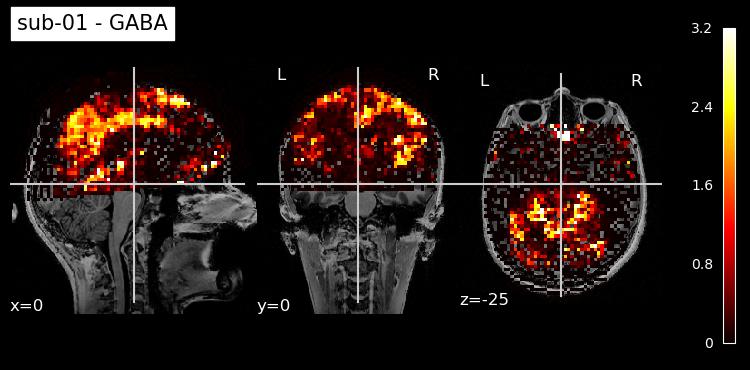

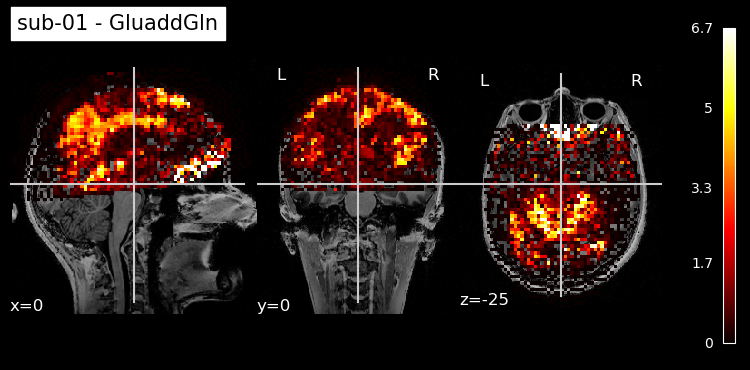

In [24]:
COVERAGE_MAPS = [
    f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Cr_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Ins_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GABA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GluaddGln_mrsi.nii.gz",
]
plot_coverage_grid(COVERAGE_MAPS, MRS_DIR, T1W_PATH, subj=SUBJ)


## 4  Native MRSI-space coverage 

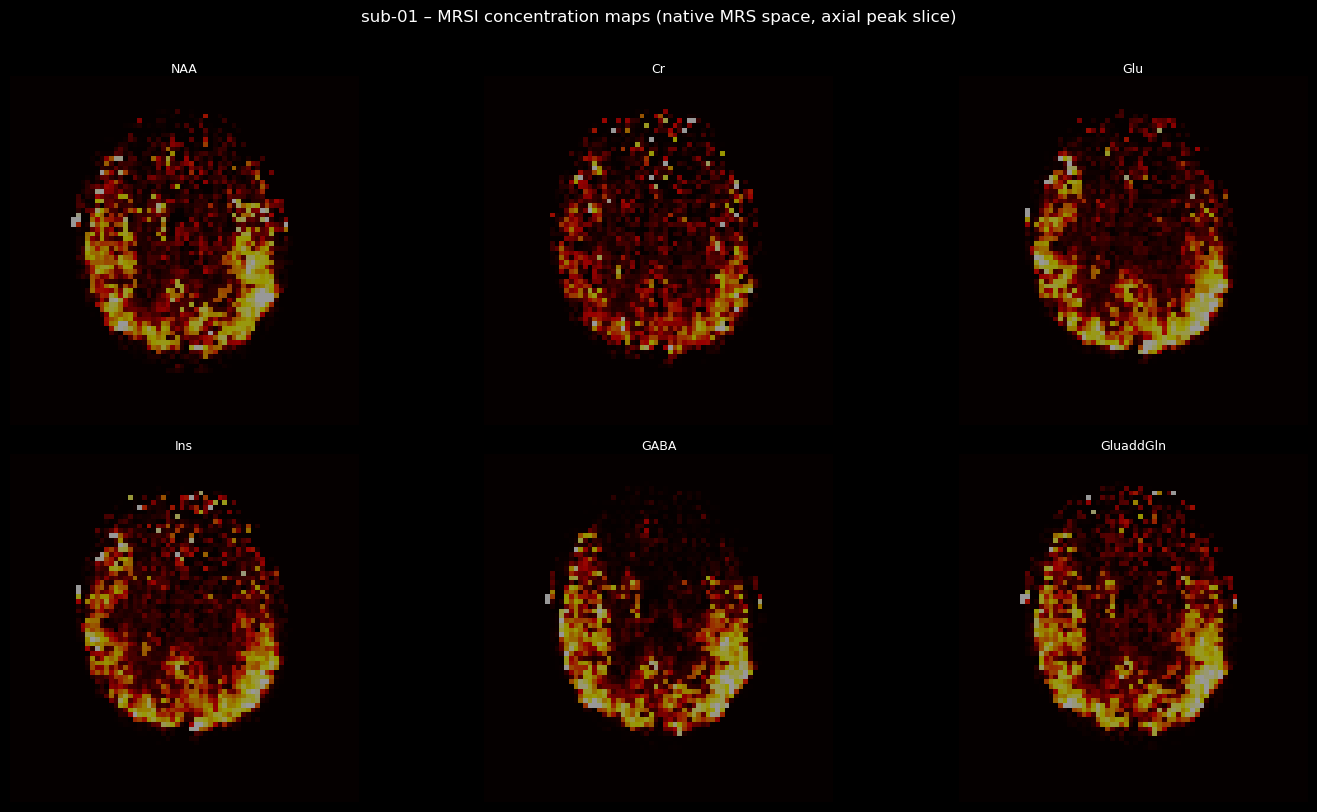

In [25]:
# one panel per metabolite, peak axial slice, normalised individually.
MOSAIC_MAPS = [
    f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Cr_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Ins_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GABA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GluaddGln_mrsi.nii.gz",
]
plot_mrsi_mosaic(MOSAIC_MAPS, MRS_DIR, subj=SUBJ, cmap="hot", cols=3)


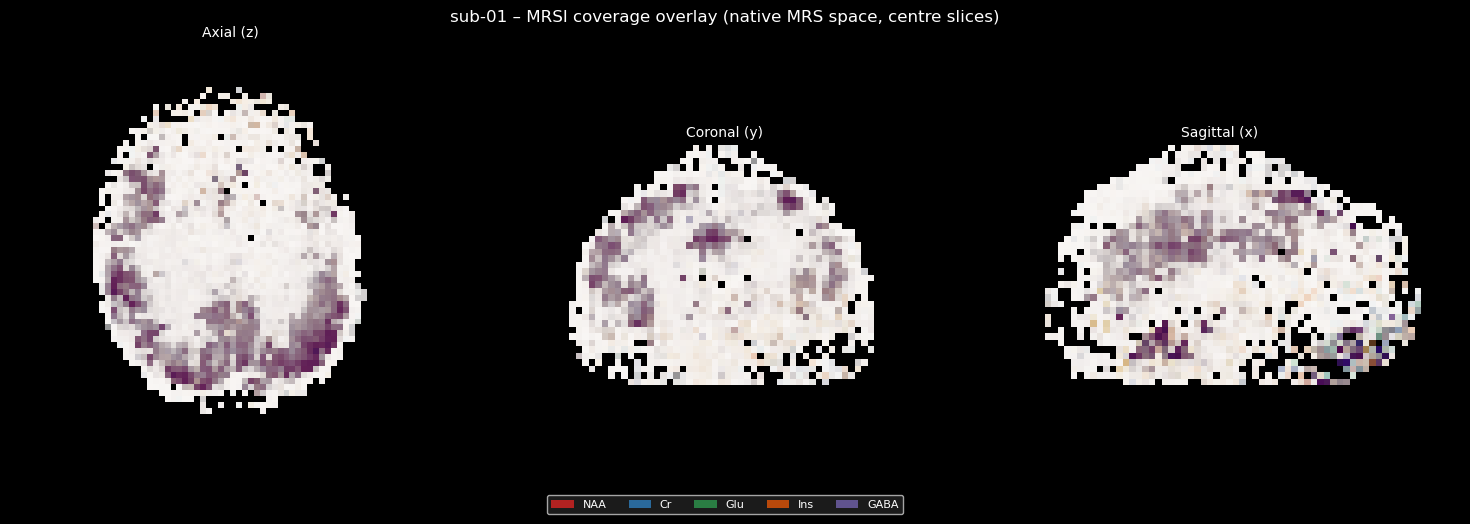

In [26]:
# Combined overlay: all maps on the same 3 views, each in its own colour.
COMBINED_MAPS = [
    f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Cr_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Ins_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GABA_mrsi.nii.gz",
]
plot_mrsi_combined(COMBINED_MAPS, MRS_DIR, subj=SUBJ, alpha=0.6)


## 5 – Support mask: pure binary spatial footprint

Binary mask of where signal exists, overlaid on the T1w.


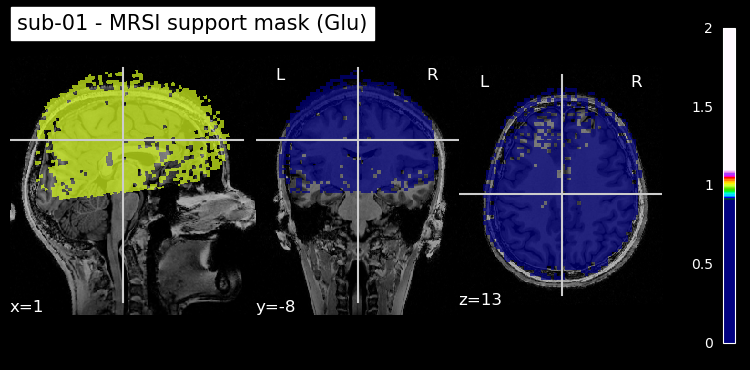

  Brain coverage: 14.1%


0.1414142215021152

In [27]:
plot_support_mask(
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    T1W_PATH, MRS_DIR, subj=SUBJ,
)

## 6 – Interactive multi-metabolite brain-coverage viewer

Use the checkboxes to pick any combination of metabolites.  
The selected maps are summed and overlaid on the T1w UNI-DEN background so you can compare spatial coverage at a glance.


In [28]:
from IPython.display import display
display(build_coverage_widget(MRS_DIR, subj=SUBJ))

## 7 – Sum of all metabolite maps (native MRS space)

`sum_img` is the voxel-wise sum of all `acq-OrigRes` concentration maps for `sub-01`, saved as a NIfTI and loaded by `main.py`.  
The mosaic below shows all 3 orthogonal centre-slice views.  
To regenerate the file for all subjects run `save_metabolite_sum(BIDS_DIR, ses=SES, overwrite=True)`.


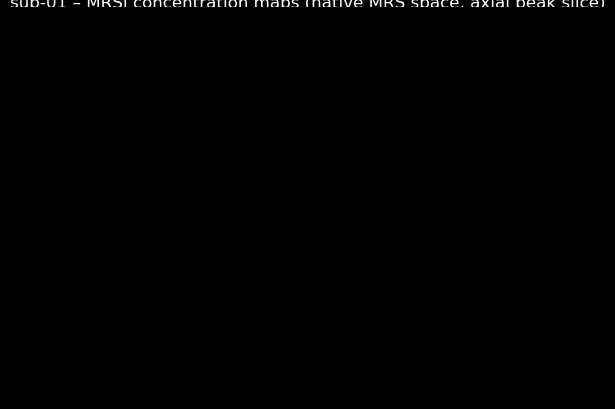

In [29]:
# visualise the all metabolite sum in native MRS space (3 orthogonal views)

plot_mrsi_mosaic([SUM_NAME], MRS_DIR, subj=SUBJ, cmap="hot", cols=1)

# visualise all 3 orthogonal centre slices side by side
plot_mrsi_combined([SUM_NAME], MRS_DIR, subj=SUBJ, cmaps=["hot"], alpha=0.9)


## 8 – Downsampled T1w at MRSI resolution

The T1w UNI-DEN image is resampled to the exact voxel grid of the MRSI concentration maps and saved as  
`anat/<subj>_<ses>_acq-MRSIres_T1w.nii.gz` for every subject that has an `anat/` folder.

The panel below shows (per row):
1. Downsampled T1w – axial, coronal, sagittal centre slices  
2. An MRSI concentration map at the same grid  
3. Their overlay (T1w grey + MRSI colour)


=== Downsampled T1w ===
T1w @ MRS res  (sub-01_ses-01_acq-MRSIres_T1w.nii.gz)
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32

MRS ref        (sub-01_ses-01_acq-OrigRes_desc-2HG_mrsi.nii.gz)
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32



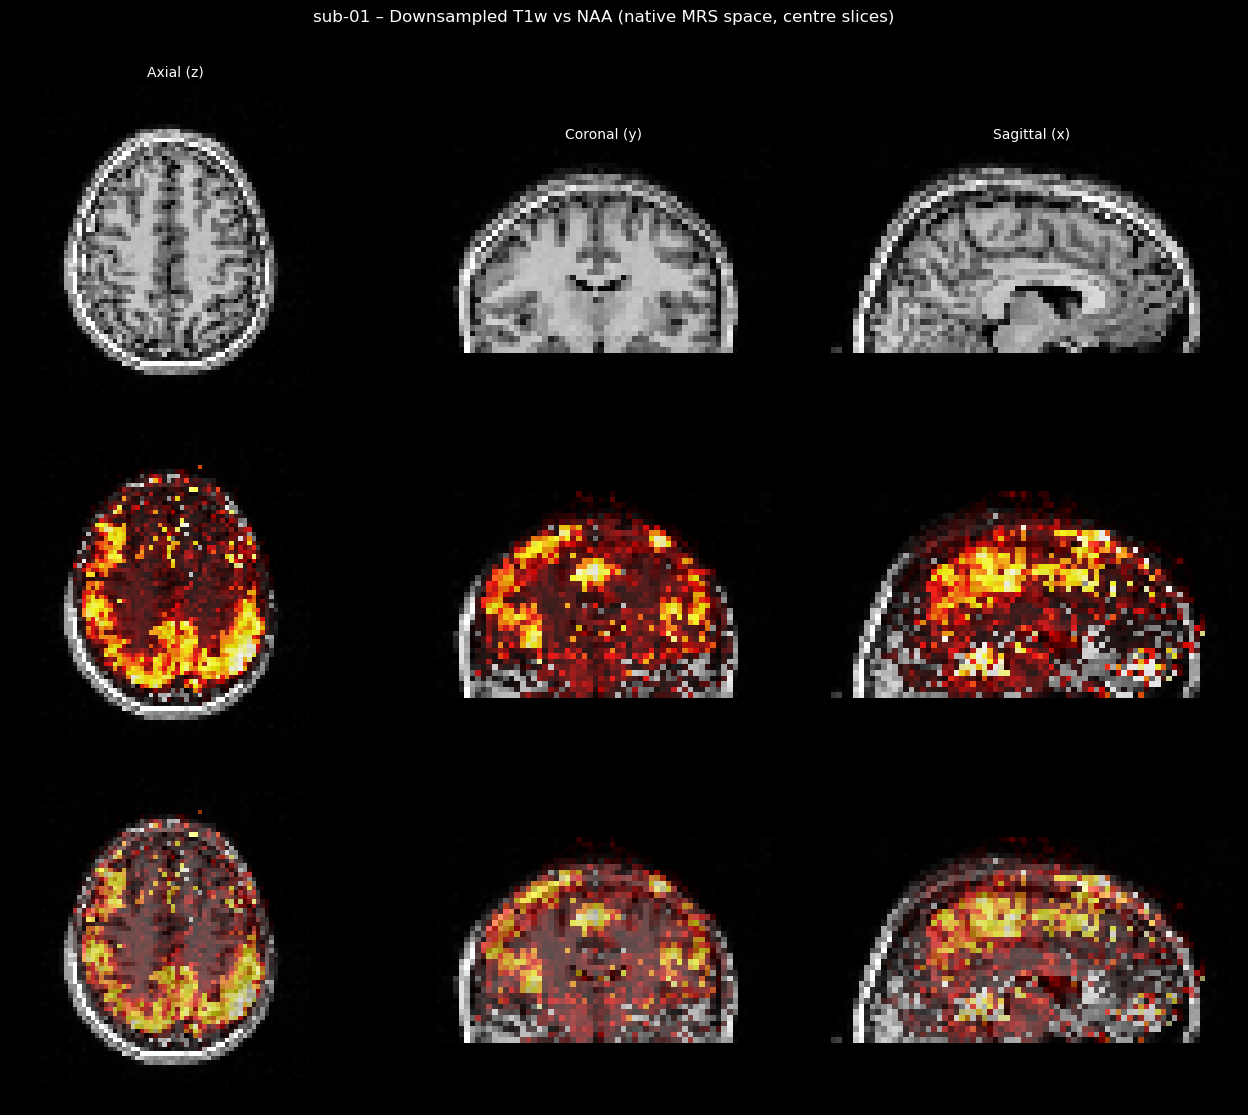

In [30]:

print("=== Downsampled T1w ===")
img_info(t1w_ds_img, f"T1w @ MRS res  ({T1W_DS_NAME})")
img_info(mrs_example, f"MRS ref        ({mrs_files[0]})")

# pick NAA as the representative metabolite for the overlay comparison
_ref_metab = f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz"
import nibabel as nib, os
_mrs_img = nib.load(os.path.join(MRS_DIR, _ref_metab))

plot_t1w_mrs_comparison(
    t1w_ds_img,
    _mrs_img,
    subj=SUBJ,
    mrs_label="NAA",
    )


## 9 – Best-SNR metabolite map

All `acq-OrigRes` concentration maps are ranked by their mean VoxelSNR**  the scanner derived per voxel SNR map (`desc-VoxelSNR_mrsi`) averaged over the support mask of each metabolite.

The bar chart shows mean and median SNR alongside spatial coverage (number of valid voxels).  
The best-ranked map is then displayed as a mosaic (peak axial slice per map) and as a combined ortho overlay.


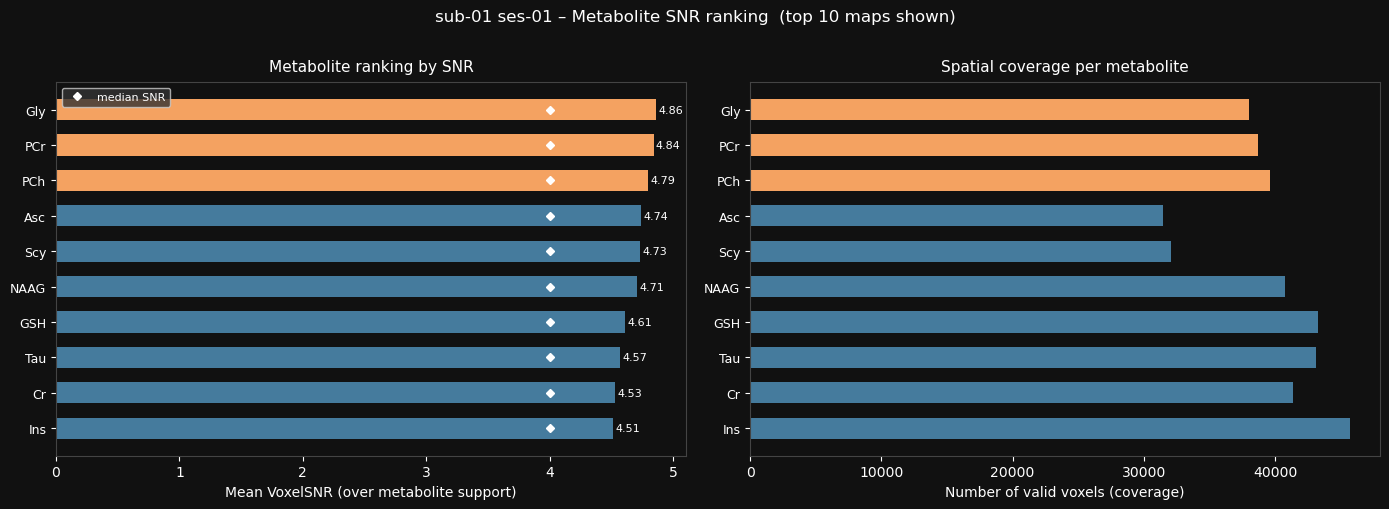


Top-3 metabolites by mean VoxelSNR:
  # 1  Gly                        mean_SNR=4.86  median_SNR=4.00  n_voxels=38,015  CV=9.187
  # 2  PCr                        mean_SNR=4.84  median_SNR=4.00  n_voxels=38,708  CV=4.719
  # 3  PCh                        mean_SNR=4.79  median_SNR=4.00  n_voxels=39,631  CV=2.344


In [31]:
# rank all metabolites by SNR using the scanner-provided VoxelSNR map
snr_records = rank_metabolites_by_snr(MRS_DIR, subj=SUBJ, ses=SES)

# bar chart: mean/median SNR + coverage for the top-20 maps
plot_snr_ranking(snr_records, top_n=10, highlight_best=3)


Best SNR metabolite: Gly  (mean_SNR=4.86)


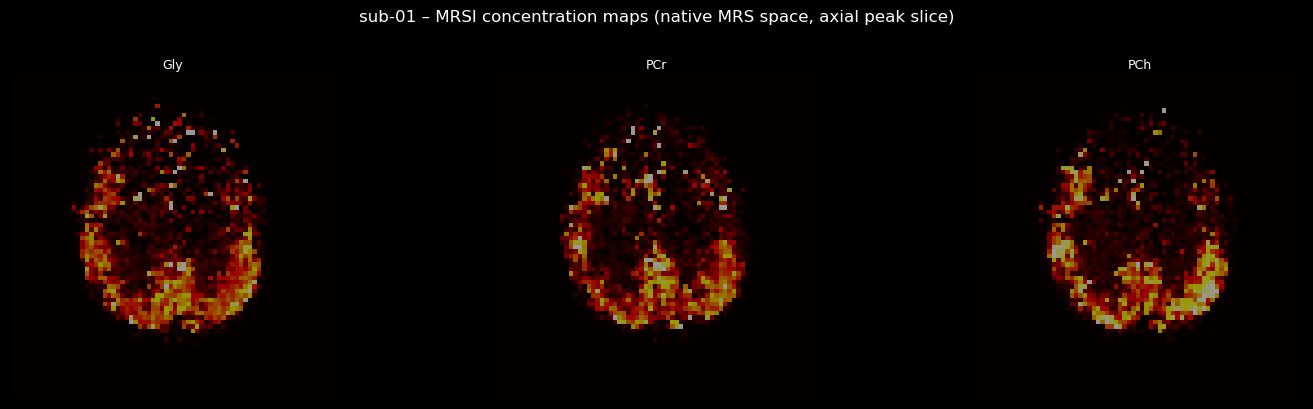

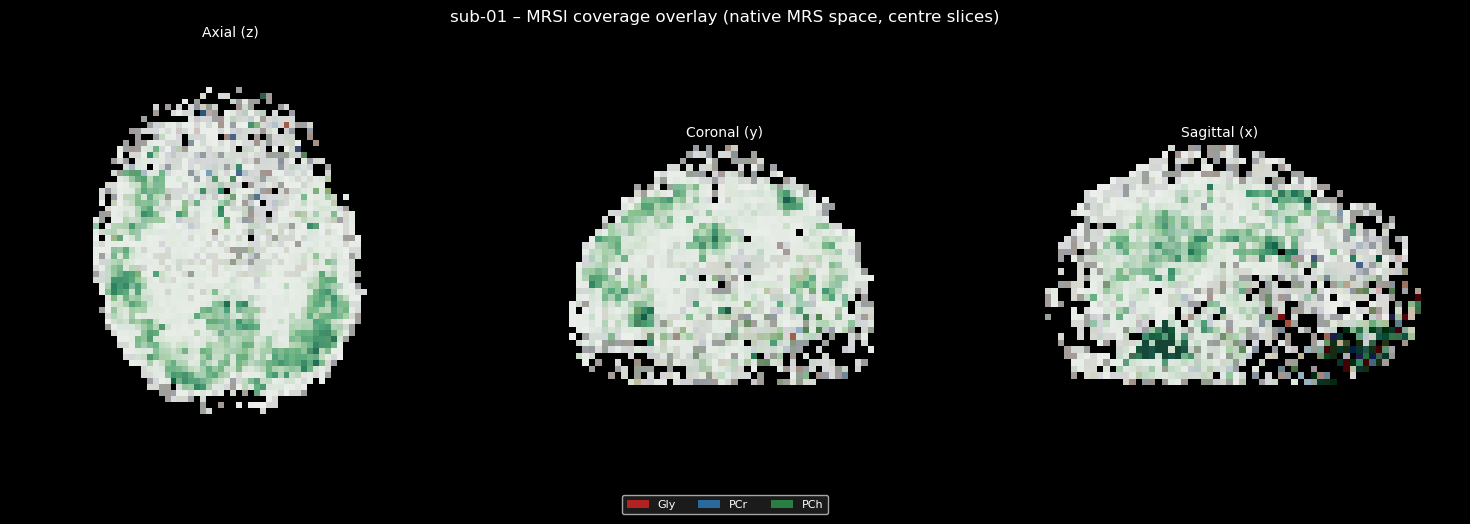

In [32]:
# visualise the best-SNR map and the top-3 together
best = snr_records[0]
top3 = [r["filename"] for r in snr_records[:3]]

print(f"Best SNR metabolite: {best['metabolite']}  (mean_SNR={best['mean_snr']:.2f})")

# mosaic: peak axial slice for each of the top-3 maps
plot_mrsi_mosaic(top3, MRS_DIR, subj=SUBJ, cmap="hot", cols=3)

# combined ortho overlay of the top-3, each in its own colour
plot_mrsi_combined(top3, MRS_DIR, subj=SUBJ, alpha=0.65)


## 10 – Water mask: raw vs hole-filled comparison

Side-by-side visual comparison of:
- **Raw mask** — binary threshold on the WaterSignal image (`value > 0`)
- **Filled mask** — same mask after `fill_mask_holes` (scipy `binary_fill_holes`)
- **Hole map** — voxels that were missing in the raw mask but recovered by filling


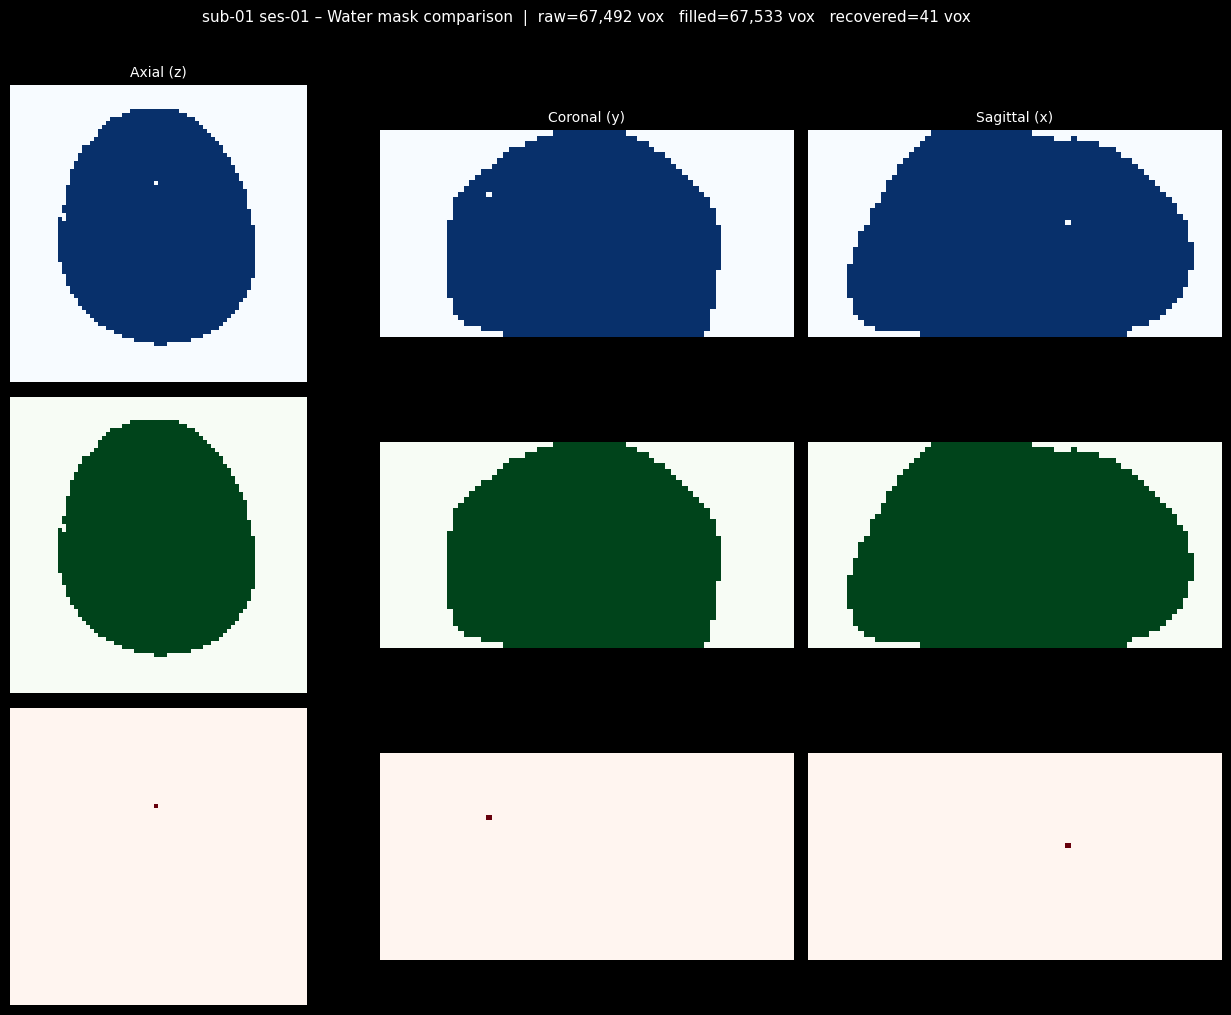

Raw mask voxels   : 67,492
Filled mask voxels: 67,533
Holes recovered   : 41  (0.06% of filled mask)


In [33]:
plot_water_mask_comparison(water_img, mask, subj=SUBJ, ses=SES)


## 11 – T1w/MRSI registration: before vs after

The downsampled T1w is masked with the filled water mask and then rigidly registered to the best-SNR MRSI map using ANTsPy. Because both images come from the same subject and session, a rigid transform is sufficient.

Left column: unregistered downsampled T1w overlaid on MRSI.  
Right column: registered T1w overlaid on the same MRSI map.


Best-SNR metabolite used as registration target: Gly


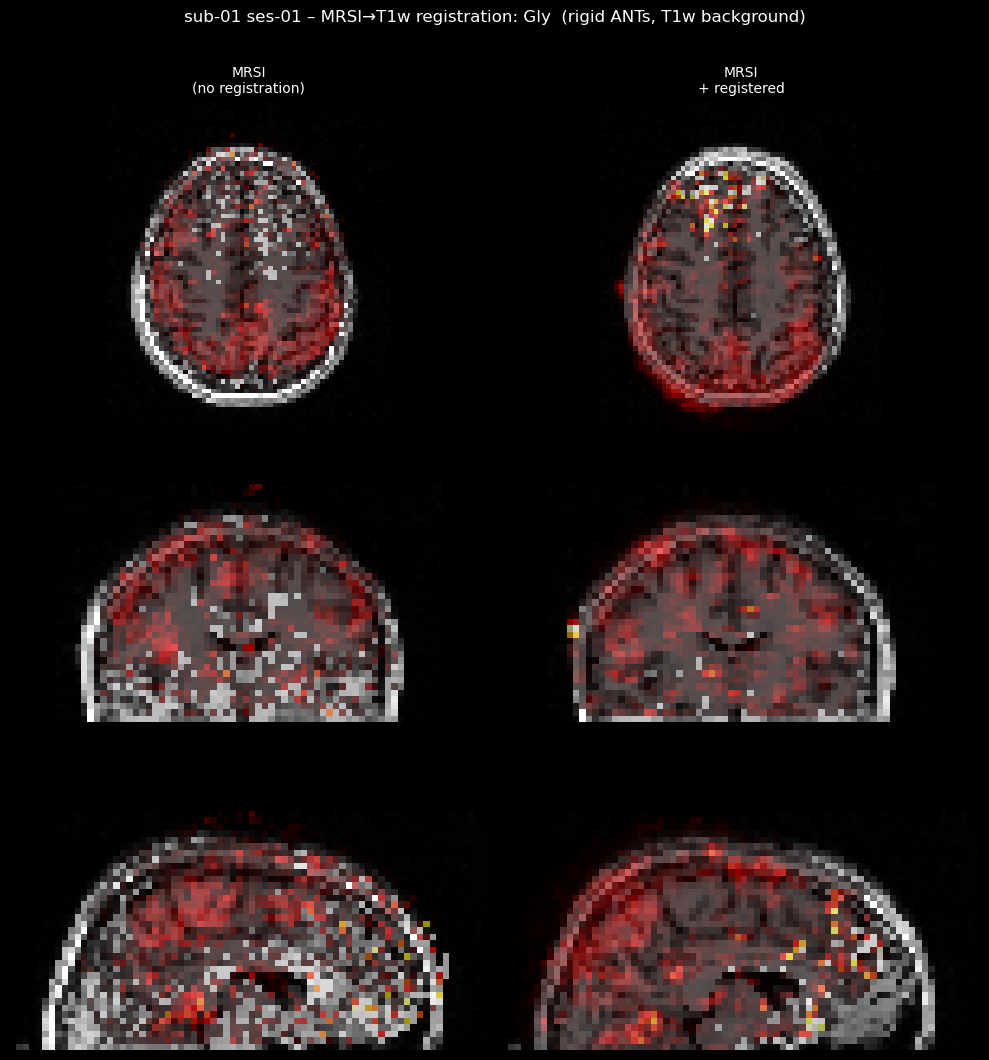

In [34]:
print(f"Best-SNR metabolite used as registration target: {best_mrsi_label}")
plot_registration_comparison(
    t1w_ds_img,
    best_mrsi_img,
    mrsi_reg_ds_img,
    subj=SUBJ,
    ses=SES,
    mrsi_label=best_mrsi_label,
)


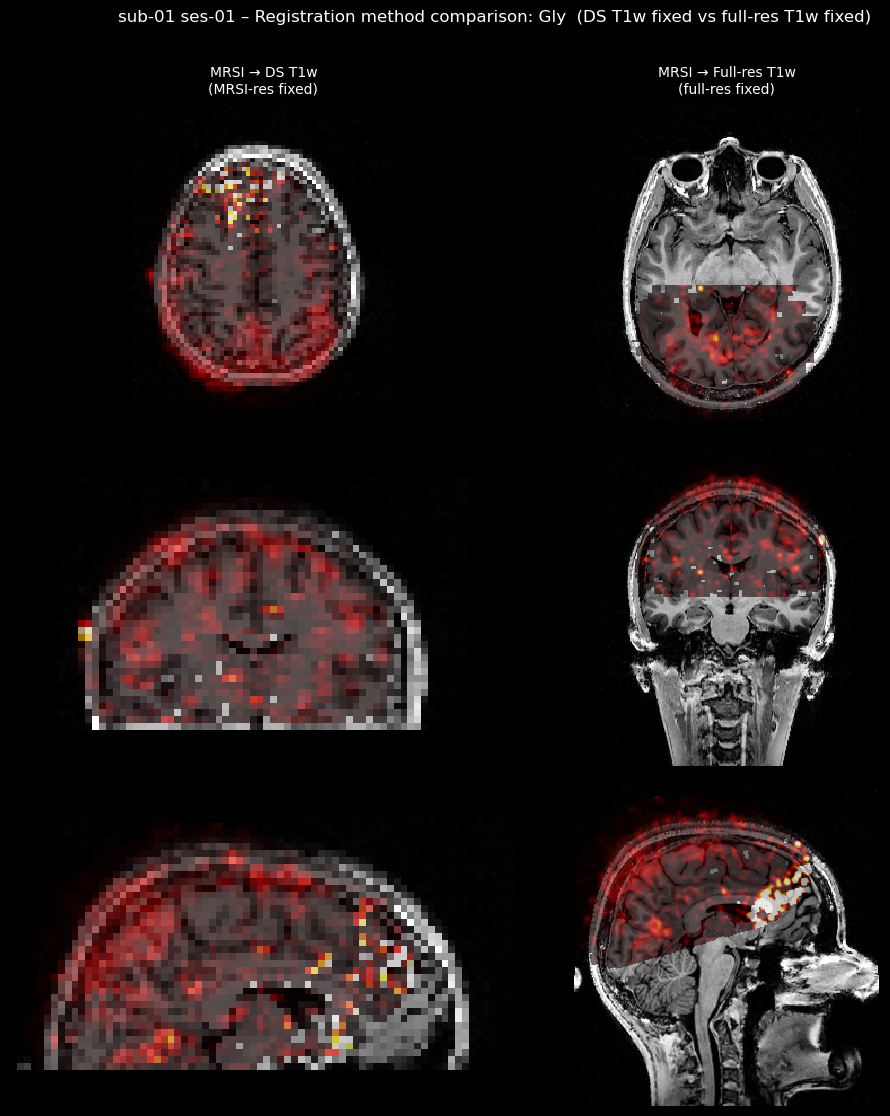

In [35]:
# Compare the two registration strategies, both in T1w space:
#   Left  - MRSI registered to DS T1w (MRSI-res fixed)
#   Right - MRSI registered to full-resolution T1w (full-res fixed)
plot_registration_methods_comparison(
    t1w_ds_img,
    t1w_img,
    mrsi_reg_ds_img,
    mrsi_reg_fullres_img,
    subj=SUBJ,
    ses=SES,
    mrsi_label=best_mrsi_label,
)


## 12 – Registration target comparison: best-SNR metabolite vs metabolite sum

Two strategies for choosing the moving image to register to the downsampled T1w (rigid ANTs):

- Left  image = best-SNR metabolite map  
- Right image = voxel-wise sum of all metabolite maps



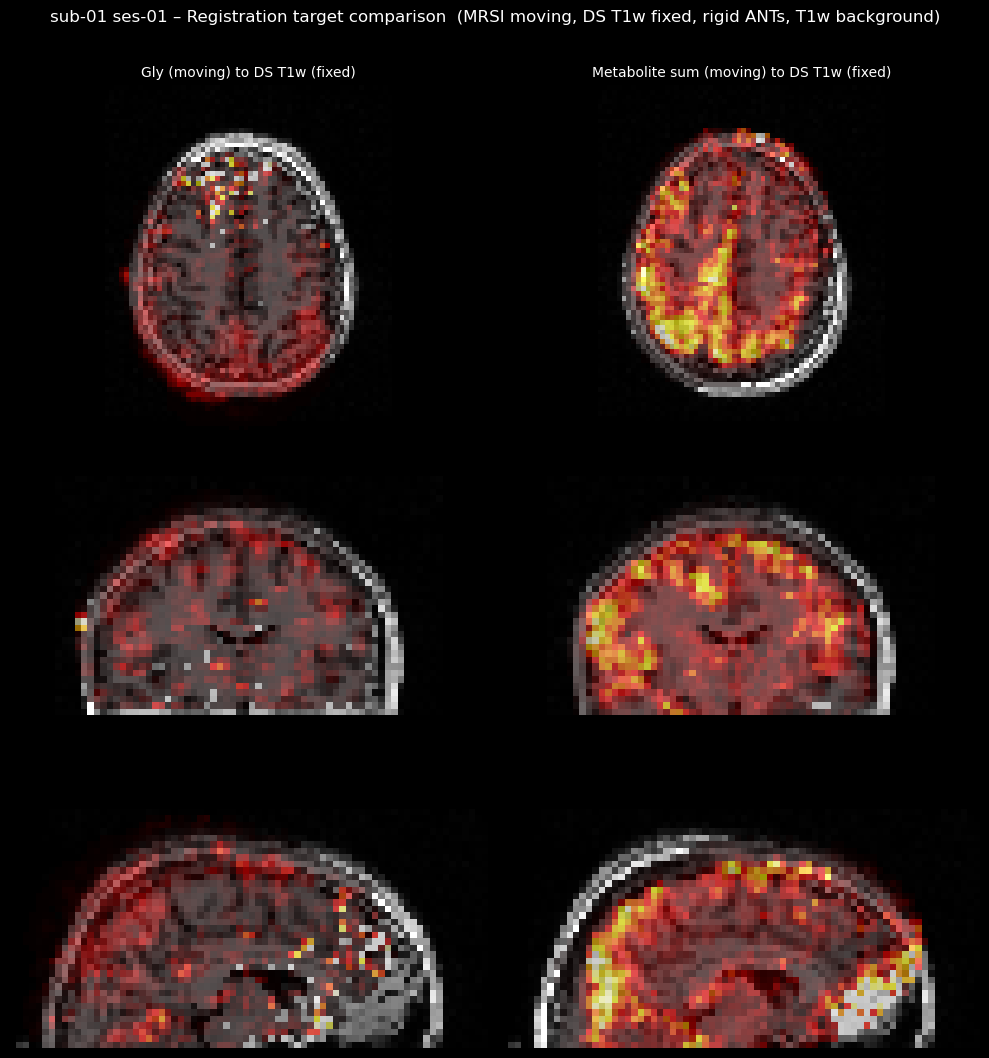

In [36]:
plot_registration_target_comparison(
    t1w_ds_img,
    mrsi_reg_ds_img,
    mrsi_sum_reg_img,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)


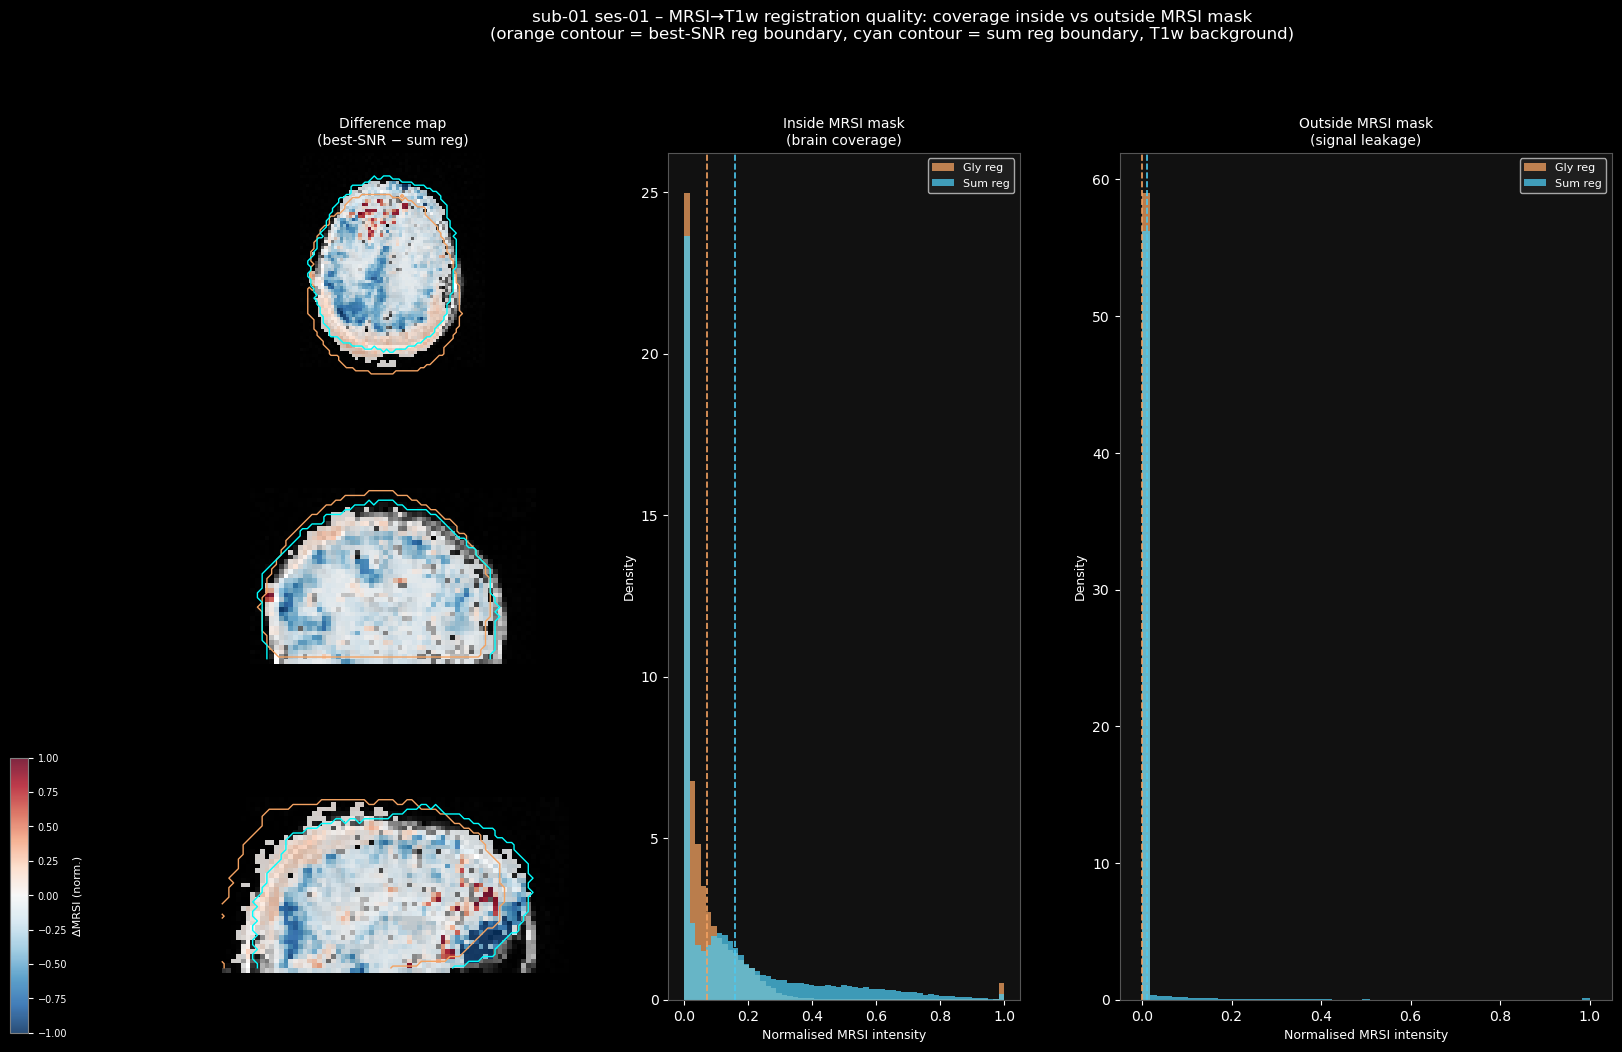

Metric                          best-SNR reg         Sum reg    Δ (best−sum)
────────────────────────────────────────────────────────────────────────────
Mean MRSI in-mask                     0.0724          0.1588         -0.0864
Mean MRSI out-of-mask                 0.0000          0.0103         -0.0103
In/Out SNR ratio               72425320.7445         15.4554  +72425305.2892
% active voxels in-mask              38.3609         53.1773        -14.8164
% active voxels out                   0.0000          3.6923         -3.6923


In [37]:
# Quantitative coverage comparison: in-mask vs out-of-mask MRSI intensity
# + signed difference map (best-SNR reg - sum reg) + metrics table
# Two contours show where each registration places the MRSI FOV boundary:
#   orange = best-SNR (Gly) registration,  cyan = sum registration
metrics = compare_registration_coverage(
    t1w_ds_img,
    mask,
    best_mrsi_img,
    mrsi_reg_ds_img,
    mrsi_sum_reg_img,
    reg1_transforms,
    reg3_transforms,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)


## 13 – Metabolite sum: independent registration vs best-SNR transform reuse

Two ways to bring the gly map into DS T1w space:
- Left independent registration: the gly image is used as the moving image and ANTs solves a new rigid transform optimised specifically for it.
- Right transform reuse: the rigid transform already solved for the sum image is applied directly to the sum, with no re optimisation.


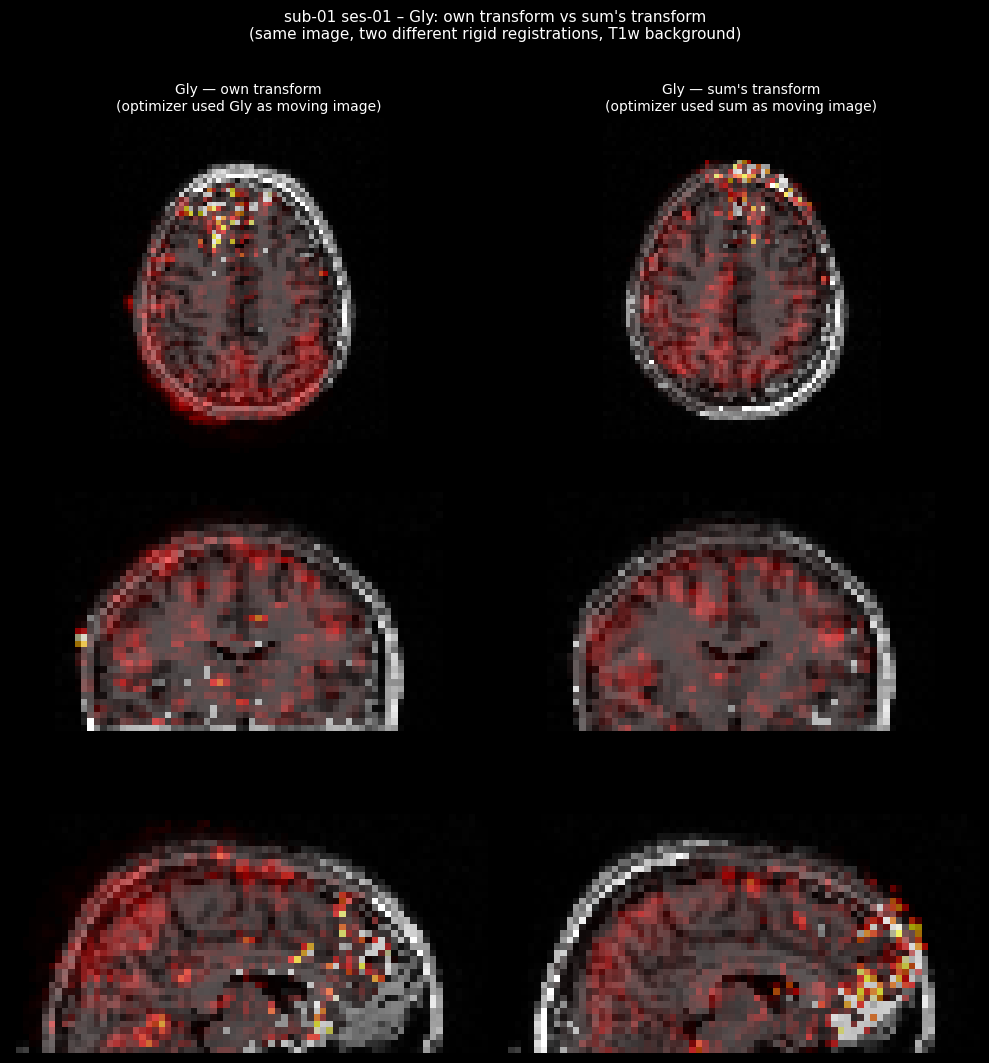

                                   mean in brain   CC with T1w
  ----------------------------------------------------------
  Gly — own transform                     0.0716        0.0545
  Gly — sum's transform                   0.0632        0.0392


In [38]:
plot_sum_registration_comparison(
    t1w_ds_img,
    mrsi_reg_ds_img,
    mrsi_gly_via_sum_img,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)

## 14 – Coverage-based vs SNR-based registration: three-way comparison

Three ways of placing the **Gly** map (best-SNR metabolite) and the **best-coverage** metabolite into DS T1w space, all compared side by side:

- **Left** — best-coverage metabolite (e.g. Ins) with its **own** rigid transform. Broader signal gives ANTs more overlap to lock onto.
- **Centre** — Gly with its **own** rigid transform (Reg 1): the optimal transform for Gly — used as the reference throughout.
- **Right** — Gly with the **metabolite sum’s transform** (Reg 3) applied directly, no re-optimisation. Shows the error introduced by using an aggregate map as the registration target.

The metrics table below each figure reports mean in-brain intensity and correlation with the T1w for each strategy.

Best-coverage metabolite : MM14addLip13aaddLip13baddMM12  (49036 voxels)
Best-SNR (Gly)           : Gly  (38015 voxels)


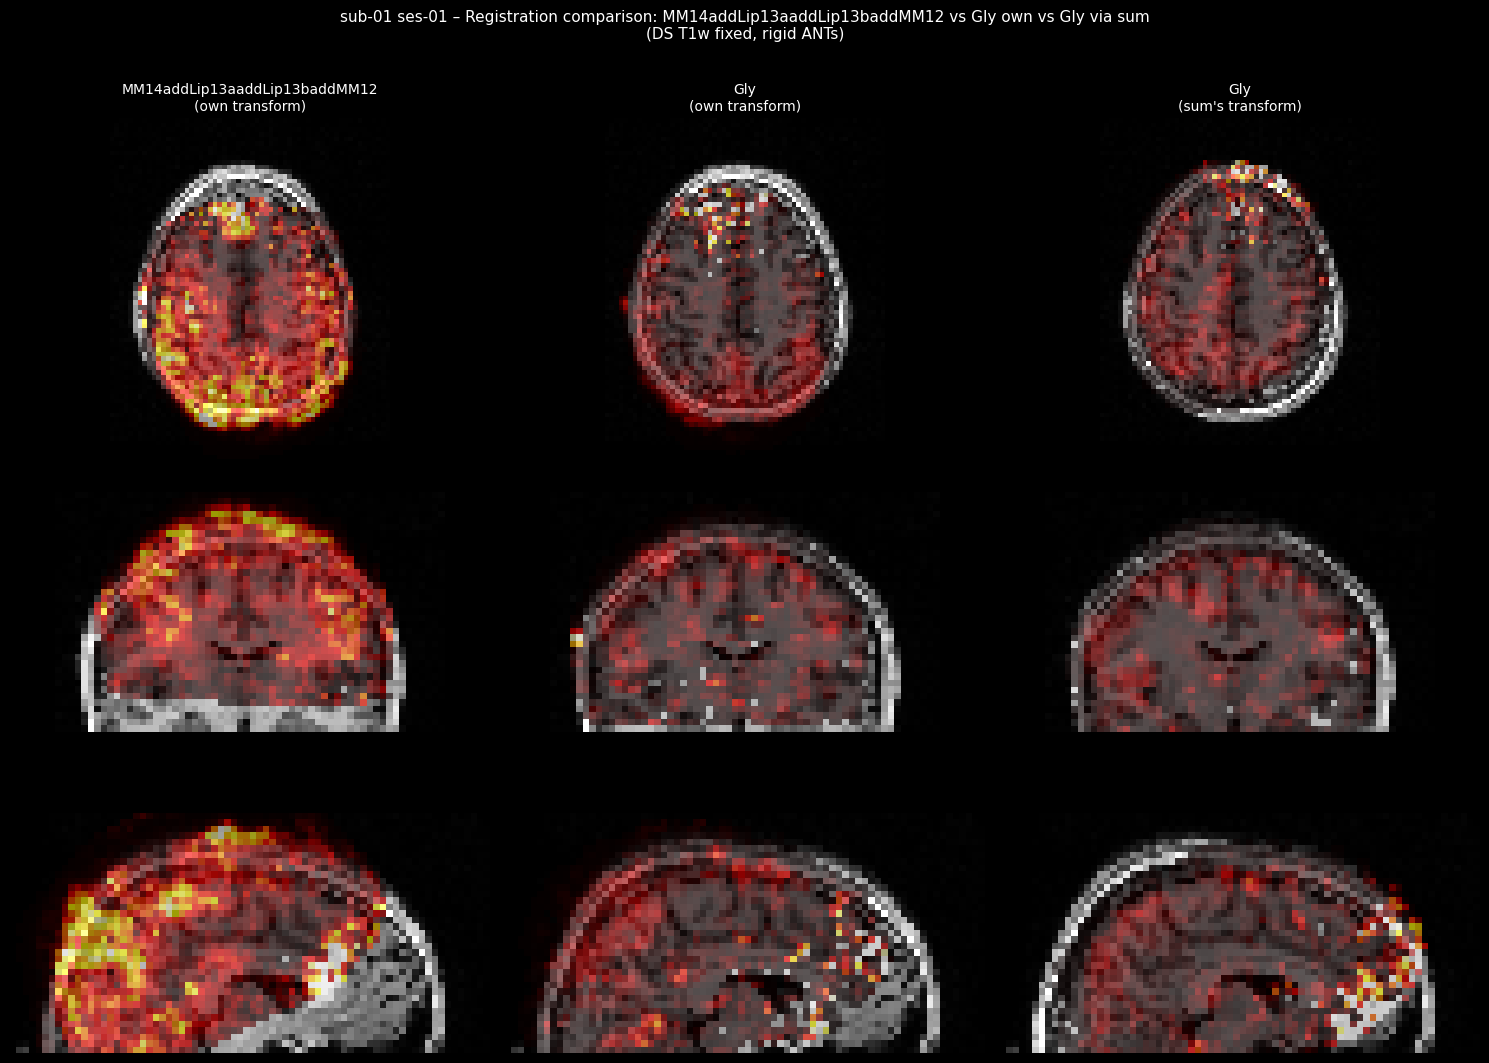


  Strategy                               Mean in brain   CC with T1w
  ------------------------------------------------------------------
  MM14addLip13aaddLip13baddMM12 — own transform          0.2000       -0.0363
  Gly — own transform                           0.0716        0.0545
  Gly — sum's transform                         0.0632        0.0392


In [39]:
print(f"Best-coverage metabolite : {best_cov_label}  ({coverage_records[0]['n_voxels']} voxels)")
print(f"Best-SNR (Gly)           : {best_mrsi_label}  ({snr_records[0]['n_voxels']} voxels)")

plot_coverage_registration_comparison(
    t1w_ds_img,
    mrsi_cov_reg_img,
    mrsi_reg_ds_img,
    mrsi_gly_via_sum_img,
    subj=SUBJ,
    ses=SES,
    cov_label=best_cov_label,
    gly_label=best_mrsi_label,
)


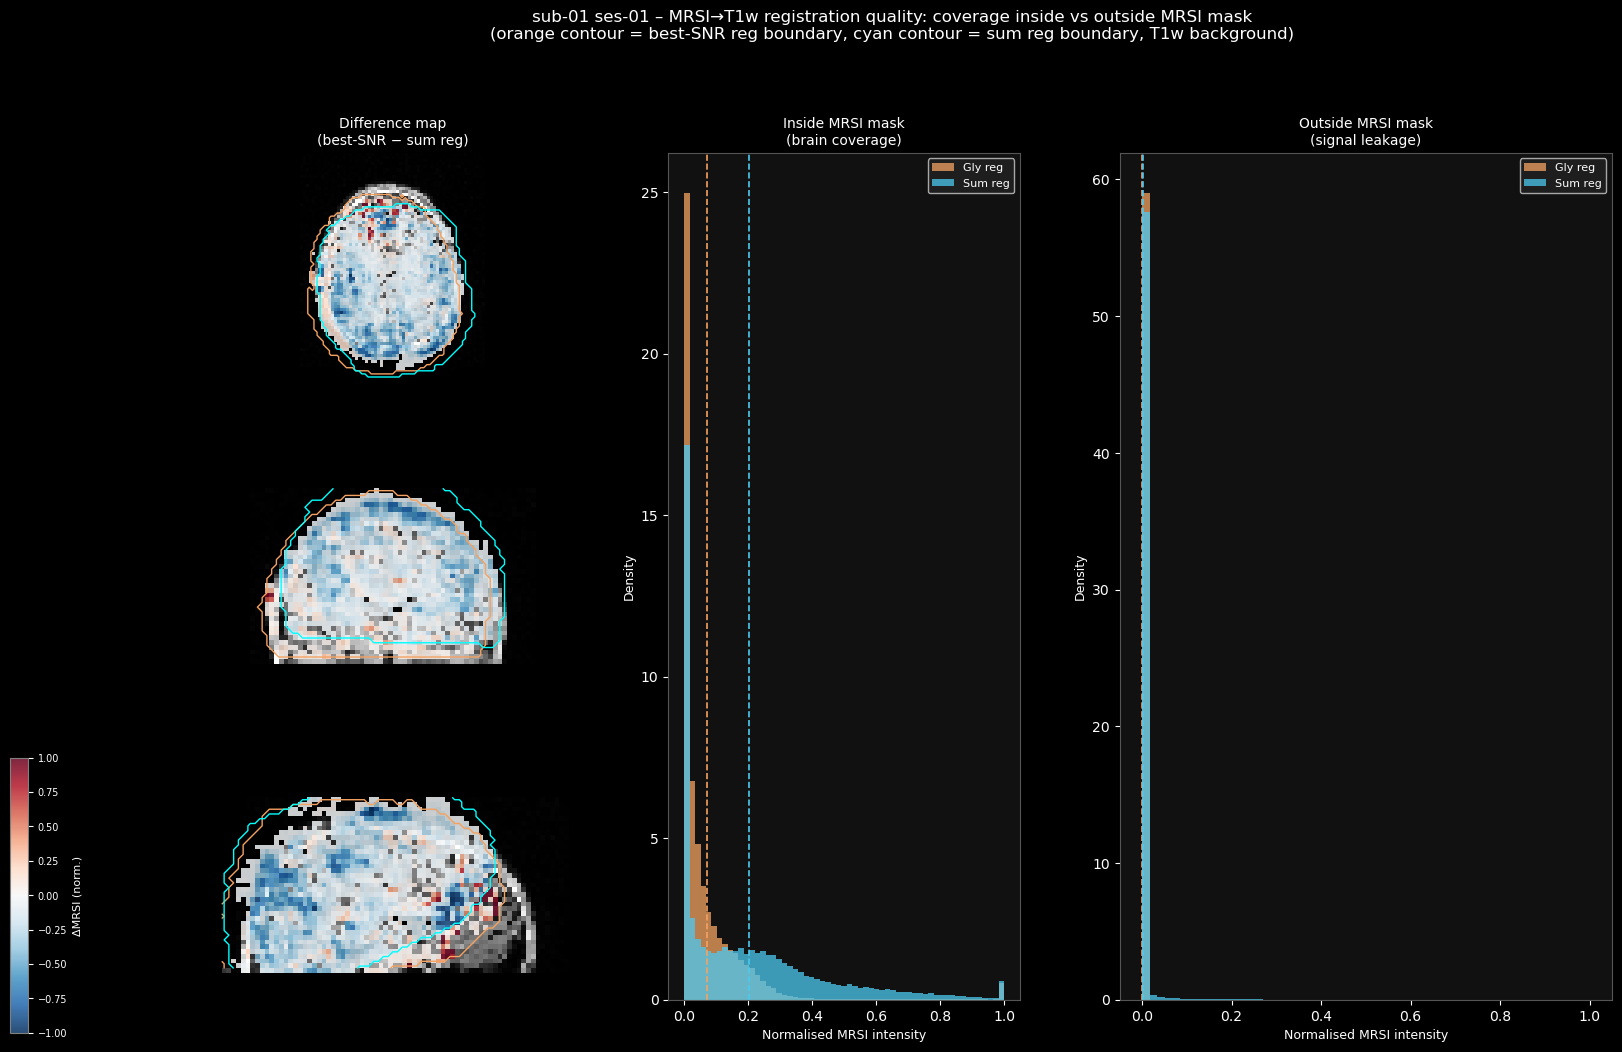

Metric                          best-SNR reg         Sum reg    Δ (best−sum)
────────────────────────────────────────────────────────────────────────────
Mean MRSI in-mask                     0.0724          0.2035         -0.1311
Mean MRSI out-of-mask                 0.0000          0.0027         -0.0027
In/Out SNR ratio               72425320.7445         76.0485  +72425244.6960
% active voxels in-mask              38.3609         63.5971        -25.2362
% active voxels out                   0.0000          1.3946         -1.3946


{'best_snr': {'mean_in': 0.07242532074451447,
  'mean_out': 0.0,
  'snr_ratio': 72425320.74451447,
  'pct_active_in': 38.36089516362143,
  'pct_active_out': 0.0},
 'sum': {'mean_in': 0.20352111756801605,
  'mean_out': 0.00267620082013309,
  'snr_ratio': 76.0484938157223,
  'pct_active_in': 63.5970850892273,
  'pct_active_out': 1.3946420613525616}}

In [40]:
compare_registration_coverage(
    t1w_ds_img,
    mask,
    best_mrsi_img,
    mrsi_reg_ds_img,
    mrsi_cov_reg_img,
    reg1_transforms,
    reg6_transforms,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)
